# **Validation Methods:**
Validation methods are methods that we use to evaluate the performance and characteristic of our model and helps in choosing the best model for our task based-on our needs.

methods:
- Validation Curve
- Learning Curve

## Validation Curve:

This method helps us to have the train and test scores using cross validation so that the score is a great representation of that evaluation method for the model. We specify a parameter of the model/pipeline and then give the parameter range then the function gives us the training and testing score of the model in for the parameter's range so we can decide which value for the parameter is the best and avoid the underfittind and overfitting of the model.

In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import validation_curve, learning_curve
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [157]:
wine_data = datasets.load_wine()
wine = pd.DataFrame(
	data=wine_data.data,
    columns=wine_data.feature_names
)
wine['target'] = wine_data.target

wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [158]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [159]:
wine['target'] = wine['target'].astype("category")

In [160]:
wine.dtypes

alcohol                          float64
malic_acid                       float64
ash                              float64
alcalinity_of_ash                float64
magnesium                        float64
total_phenols                    float64
flavanoids                       float64
nonflavanoid_phenols             float64
proanthocyanins                  float64
color_intensity                  float64
hue                              float64
od280/od315_of_diluted_wines     float64
proline                          float64
target                          category
dtype: object

In [161]:
X = wine.loc[:, "alcohol": "proline"].to_numpy()
y = wine['target'].to_numpy()

X.shape, y.shape

((178, 13), (178,))

In [162]:
assert X.shape[0] == y.shape[0], "Number of sampled not match"
assert len(X.shape) == 2, "X should be a 2-dimensional array"
assert len(y.shape) == 1, "y should be a 1-dimensional array"

In [163]:
print(f"Number of total samples: {X.shape[0]}")

Number of total samples: 178


In [164]:
# scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X, y)

# training the model
svc = SVC(C=1)
train_score, test_score = validation_curve(
    estimator=svc,
    X=X_scaled,
    y=y,
    param_name="C",
    param_range=np.linspace(0.1, 10, 20),
    cv=5,
    n_jobs=-1, 
    scoring="accuracy" # the default value
)

In [165]:
C = np.linspace(0.1, 10, 20)
C_list = []
for i in range(20):
    C_list += [C[i]] * 5

validation_df = pd.DataFrame()
validation_df['C'] = C_list
validation_df['train_score'] = train_score.ravel()
validation_df['test_score'] = test_score.ravel()
validation_df['diff'] = validation_df['train_score'] - validation_df['test_score']

validation_df

,C,train_score,test_score,diff
0,0.1,0.985915,0.972222,0.013693
1,0.1,0.992958,0.972222,0.020736
2,0.1,0.985915,0.944444,0.041471
3,0.1,0.972028,0.942857,0.029171
4,0.1,0.986014,1.000000,-0.013986
...,...,...,...,...
95,10.0,1.000000,1.000000,0.000000
96,10.0,1.000000,0.972222,0.027778
97,10.0,1.000000,0.972222,0.027778
98,10.0,1.000000,1.000000,0.000000


(0.0, 10.0)

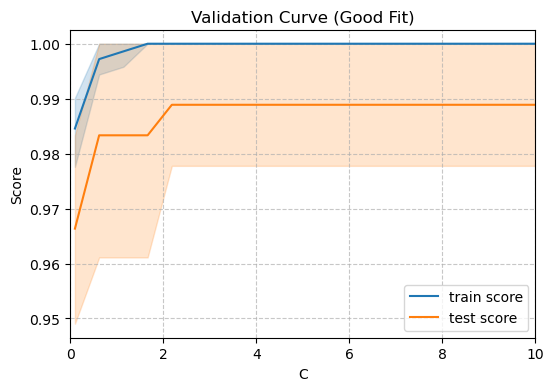

In [166]:
fig , ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=validation_df,
    x="C",
    y="train_score",
    errorbar=("ci", 95),
    label="train score"
)
sns.lineplot(
    data=validation_df,
    x="C",
    y="test_score",
    errorbar=("ci", 95),
    label="test score",
)

ax.set(
    title="Validation Curve (Good Fit)",
    ylabel="Score"
)
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_xlim(0, 10)

In [170]:
# we can have the training and testing scores of a model with cross validation using validation_curve
from sklearn.linear_model import LogisticRegression

# load the data
X, y = datasets.load_iris(return_X_y=True)

# scaling
X_scaled = StandardScaler().fit_transform(X)

# training the model and evaluation
lr_model = LogisticRegression()
train_score, test_score = validation_curve(
    estimator=lr_model,
    X=X_scaled,
    y=y,
    param_name="C",
    param_range=np.array([1])
)

In [171]:
print(f"training score: {train_score.mean(axis=1)}")
print(f"testing score: {test_score.mean(axis=1)}")

training score: [0.97]
testing score: [0.96]


## Learning Curve:

**Bias, Variance, Noise:**

> Note: Bias and variance are from the model and noise is from the data.

**Bias:** is related to the complexibility of our model and depends-on the fact that the model can capture the relationships in the real-world task or not. High bias means our model is not complex enough to capture the relationships and underfitting could happen in this scenario. Low biad means our model can capture the complex patterns in the data but it comes with overfitting problem.

**Variance:** is related to looking at the data and when variance of the model is low means we can't capture the patterns in the data using this model if it's very close to 0 (mostly) but in general low variance is good and is one of the goals of predictiion. High variance means we're looking at the data a lot and we are modeling the noise and fluctuations in the data so we are overfitting to the data and our model's generalization is low.

Learning curve is another useful function in scikit learn that gives us the ability to have the learning curve of the model for different training set sizes and we can evaluate the generalization of the model.

If there is a significant distance between training and testing score (testing score is always lower or equal to the training set if there is no problem in the workflow) at the starting points of the curve and then testing score converges to the training score at the last points of the curve so we can tell there is `underfitting` in our model (bias high, variance low).

If the testing score converges to the training score very soon or at the middle parts of the curve or any other combinations so we can say this is a `good fit` situation (bias-variance balance).

If we see convergences can divergences that the testing score is converging to the training score and by increasing the number of training examples it diverge from the training score it means thet we overfit to the data cause `overfitting` means sensitivity of the model to the training model and there is low generalization in the data.

In [175]:
training_sizes, train_score, test_score = learning_curve(
    estimator=lr_model,
    X=X_scaled,
    y=y,
    train_sizes=np.linspace(0.1, 1, 5),
    cv=5,
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)

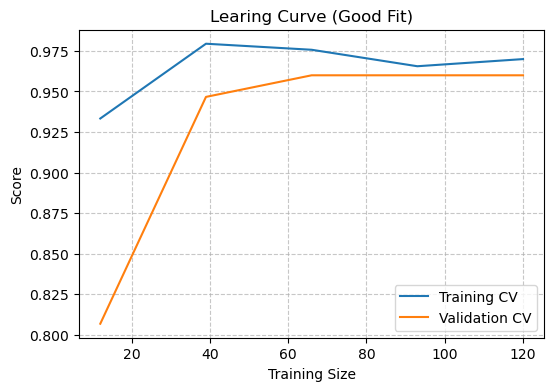

In [190]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    x=training_sizes,
    y=train_score.mean(axis=1),
    label="Training CV",
    ax=ax
)
sns.lineplot(
    x=training_sizes,
    y=test_score.mean(axis=1),
    label="Validation CV",
    ax=ax
)
ax.set(
    title="Learing Curve (Good Fit)",
    xlabel="Training Size",
    ylabel="Score"
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)